In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tslearn.clustering import TimeSeriesKMeans

In [2]:
df = pd.read_csv(
    "../../../data/DataExchangeMilan_Project2.2a/processed/design_solutions_per_scenario.csv",
    index_col=["config", "sim"]
)
df.loc["Base_cotwdpge"]

,Cable Capacity(MW),Battery Rated Power(MW),Cable Material Cost($M),Battery Cost($M),Day-Ahead Revenue ($k),Real-Time Revenue ($k),Reserve WF Revenue ($k),Reserve ESS Revenue ($k)
sim,,,,,,,,
22,2600.0,36.2,261.818246,32.184081,53.342842,-11.589288,0.004268,0.004710
23,2600.0,36.2,261.818246,32.184081,53.342842,-3.006324,0.000850,0.002057
24,2600.0,36.2,261.818246,32.184081,53.342842,-5.214967,0.001355,0.001465
25,2600.0,36.2,261.818246,32.184081,53.342842,2.644101,0.000654,0.000158
26,2600.0,36.2,261.818246,32.184081,53.342842,17.872314,0.023466,0.004765
...,...,...,...,...,...,...,...,...
117,2600.0,36.2,261.818246,32.184081,1.201874,0.073118,0.000046,0.001611
118,2600.0,36.2,261.818246,32.184081,1.201874,0.206525,0.000383,0.001360
119,2600.0,36.2,261.818246,32.184081,1.201874,-0.205468,0.000567,0.009071


In [3]:
df_scenarios = pd.read_csv(
    "../../../data/DataExchangeMilan_Project2.2a/processed/scenarios_wrevenues.csv",
    index_col=["config", "sim", "time"]
)
df_scenarios.loc["Base_cotwdpge"]

ChS      DisS        SCS       WPQ       WSQ  kBS       kWS  \
sim time                                                                     
22  0     0.005304  0.002016  72.400653  0.000000  1.631244  2.0  0.000000   
    1     0.006830  0.001833  72.401701  0.000000  1.631244  2.0  0.000000   
    2     0.009288  0.001677  72.403353  0.000000  1.631244  2.0  0.000000   
    3     0.013716  0.001543  72.406050  0.000000  1.631244  2.0  0.000000   
    4     0.024299  0.001415  72.411189  0.000000  1.656754  2.0  0.000000   
...            ...       ...        ...       ...       ...  ...       ...   
121 91    0.057586  0.181982   0.138868  1.143338  2.831317  2.0  0.006317   
    92    0.094833  0.116952   0.128312  0.000000  2.741472  2.0  0.000000   
    93    0.087642  0.137289   0.110534  0.000000  2.741472  2.0  0.000000   
    94    0.080859  0.173926   0.081147  0.000000  2.741472  2.0  0.000000   
    95    0.073323  0.286643   0.019080  0.000000  2.741472  2.0  0.000000   

                lam_DAQ         lam_RT     pRBDS  ...      pWSQ          v1  \
sim time                                          ...                         
22  0     111068.493725  113957.371061  1.508333  ...  0.000000  475.731414   
    1     111068.493725  111151.766882  1.508333  ...  0.000000  475.729736   
    2     111068.493725  108346.162703  1.508333  ...  0.000000  475.728057   
    3     111068.493725  105540.558524  1.508333  ...  0.000000  475.726378   
    4     100218.649657  102734.954344  1.508333  ...  0.000000  475.723523   
...                 ...            ...       ...  ...       ...         ...   
121 91    163680.830824  134271.586201  1.508333  ...  1.093234  480.217598   
    92    148412.687808  131484.129416  1.508333  ...  0.000000  475.671659   
    93    148412.687808  130878.298467  1.508333  ...  0.000000  475.671371   
    94    148412.687808  130272.467519  1.508333  ...  0.000000  475.671202   
    95    148412.687808  129666.636570  1.508333  ...  0.000000  475.670965   

                  v2        WS        pWDS       pWS  Day-Ahead Revenue ($k)  \
sim time                                                                       
22  0     475.731415  1.631244  750.441807  0.000000                1.825421   
    1     475.729736  1.631244  750.441807  0.000000                     NaN   
    2     475.728058  1.631244  750.441807  0.000000                     NaN   
    3     475.726379  1.631244  750.441807  0.000000                     NaN   
    4     475.723523  1.656754  716.536060  0.000000                1.572685   
...              ...       ...         ...       ...                     ...   
121 91    480.212294  2.831317   43.235001  1.093234                     NaN   
    92    475.671675  2.741472    4.894323  0.000000                0.003889   
    93    475.671388  2.741472    4.894323  0.000000                     NaN   
    94    475.671220  2.741472    4.894323  0.000000                     NaN   
    95    475.670985  2.741472    4.894323  0.000000                     NaN   

          Reserve ESS Revenue ($k)  Reserve WF Revenue ($k)  \
sim time                                                      
22  0                 2.756143e-05             0.000000e+00   
    1                 2.818572e-05             0.000000e+00   
    2                 2.881002e-05             0.000000e+00   
    3                 2.943431e-05             0.000000e+00   
    4                 3.005861e-05             0.000000e+00   
...                            ...                      ...   
121 91                5.802918e-07             1.807893e-09   
    92                8.794077e-08             0.000000e+00   
    93                4.331705e-08             0.000000e+00   
    94               -1.306666e-09             0.000000e+00   
    95               -4.593039e-08             0.000000e+00   

          Real-Time Revenue ($k)  
sim time                          
22  0                  -0.169856  
    1 

/var/folders/tf/rtwwbgw154zfsq8r54y1r2980000gn/T/ipykernel_24500/3878010136.py:6: PerformanceWarning: indexing past lexsort depth may impact performance.
  alpha=df_scenarios.loc["Base_cotwdpge", "Real-Time Revenue ($k)"].unstack(level=0).sum()
/var/folders/tf/rtwwbgw154zfsq8r54y1r2980000gn/T/ipykernel_24500/3878010136.py:9: PerformanceWarning: indexing past lexsort depth may impact performance.
  wind_speed_frame = df_scenarios.loc["Base_cotwdpge", "WS"].unstack(level=0).loc[:, top_10]


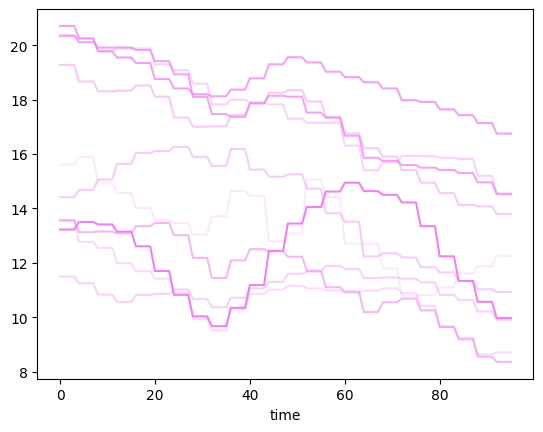

In [4]:
# Plotting wind speed with alpha representing day-ahead revenue
def min_max_scale(series):
    return (series - series.min()) / (series.max() - series.min())

# Day-Ahead Revenue ($k), Real-Time Revenue ($k)
alpha=df_scenarios.loc["Base_cotwdpge", "Real-Time Revenue ($k)"].unstack(level=0).sum()
top_10 = alpha.nlargest(10).index.values
alpha=((alpha-alpha.min())/(alpha.max()-alpha.min())).values
wind_speed_frame = df_scenarios.loc["Base_cotwdpge", "WS"].unstack(level=0).loc[:, top_10]
for i, column in enumerate(wind_speed_frame.columns):
    wind_speed_frame[column].plot(legend=False, color='violet', alpha=alpha[i])

/var/folders/tf/rtwwbgw154zfsq8r54y1r2980000gn/T/ipykernel_24500/2250855117.py:6: PerformanceWarning: indexing past lexsort depth may impact performance.
  X_scaled = df_scenarios.loc["Base_cotwdpge", "WS"].unstack(level=1)
/Users/jain432/Library/CloudStorage/OneDrive-PNNL/Milan/Workspace/PNNL Projects/pyMOODS/venv/pymoods_mac/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/jain432/Library/CloudStorage/OneDrive-PNNL/Milan/Workspace/PNNL Projects/pyMOODS/venv/pymoods_mac/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/var/folders/tf/rtwwbgw154zfsq8r54y1r2980000gn/T/ipykernel_24500/2250855117.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


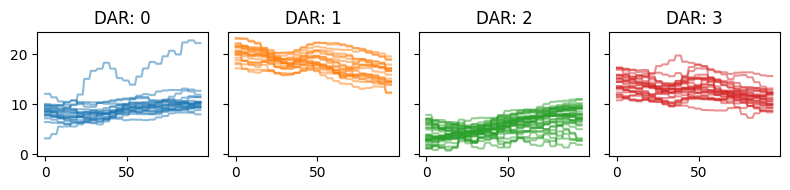

In [39]:
# model
n_clusters = 4
model = TimeSeriesKMeans(n_clusters=n_clusters, metric="dtw", max_iter=10)

# fit data
X_scaled = df_scenarios.loc["Base_cotwdpge", "WS"].unstack(level=1)
labels = model.fit_predict(X_scaled)

# visualize
n_cols = 4
n_rows = n_clusters//max_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(8, 2*n_rows), sharex=True, sharey=True)
for i in range(n_clusters):
    if n_rows == 1:
        ax = axes[i%n_cols]
    else:
        ax = axes[i//n_cols, i%n_cols]
    for j, col_name in enumerate(X_scaled.index):
        # print(j, col_name)
        if labels[j] == i:
            ax.plot(X_scaled.loc[col_name], color=f"C{i}", alpha=0.5)
    ax.set_title(f"DAR: {i}")
fig.tight_layout()
fig.show()

In [37]:
n_rows

1

In [33]:
X_scaled

time,0,1,2,3,4,5,6,7,8,9,...,86,87,88,89,90,91,92,93,94,95
sim,,,,,,,,,,,,,,,,,,,,,
22,1.631244,1.631244,1.631244,1.631244,1.656754,1.656754,1.656754,1.656754,1.853448,1.853448,...,8.028349,8.028349,7.663843,7.663843,7.663843,7.663843,7.309430,7.309430,7.309430,7.309430
23,7.112126,7.112126,7.112126,7.112126,5.979970,5.979970,5.979970,5.979970,4.916520,4.916520,...,5.907507,5.907507,5.461762,5.461762,5.461762,5.461762,4.974083,4.974083,4.974083,4.974083
24,4.901001,4.901001,4.901001,4.901001,4.158747,4.158747,4.158747,4.158747,3.793579,3.793579,...,7.439816,7.439816,6.633846,6.633846,6.633846,6.633846,5.910967,5.910967,5.910967,5.910967
25,8.585358,8.585358,8.585358,8.585358,8.692773,8.692773,8.692773,8.692773,8.409402,8.409402,...,22.307536,22.307536,22.721027,22.721027,22.721027,22.721027,22.178572,22.178572,22.178572,22.178572
26,15.607597,15.607597,15.607597,15.607597,15.883556,15.883556,15.883556,15.883556,14.945369,14.945369,...,11.613366,11.613366,11.871640,11.871640,11.871640,11.871640,12.259055,12.259055,12.259055,12.259055
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,7.016584,7.016584,7.016584,7.016584,4.841164,4.841164,4.841164,4.841164,4.509548,4.509548,...,4.844431,4.844431,4.246938,4.246938,4.246938,4.246938,3.159150,3.159150,3.159150,3.159150
118,1.114214,1.114214,1.114214,1.114214,1.538390,1.538390,1.538390,1.538390,1.351354,1.351354,...,5.077565,5.077565,4.082262,4.082262,4.082262,4.082262,2.954512,2.954512,2.954512,2.954512
119,1.784167,1.784167,1.784167,1.784167,0.844167,0.844167,0.844167,0.844167,1.507500,1.507500,...,1.320000,1.320000,2.219167,2.219167,2.219167,2.219167,1.870833,1.870833,1.870833,1.870833


In [24]:
3//4

0